# COVID-19 India Data Analysis

## Objective
Analyze COVID-19 trends and extract meaningful insights.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("covid_19_clean_complete.csv")
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [3]:
df = df[df['Country/Region'] == 'India']

In [4]:
print(df.columns)

Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='object')


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 188 entries, 129 to 48936
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  0 non-null      object 
 1   Country/Region  188 non-null    object 
 2   Lat             188 non-null    float64
 3   Long            188 non-null    float64
 4   Date            188 non-null    object 
 5   Confirmed       188 non-null    int64  
 6   Deaths          188 non-null    int64  
 7   Recovered       188 non-null    int64  
 8   Active          188 non-null    int64  
 9   WHO Region      188 non-null    object 
dtypes: float64(2), int64(4), object(4)
memory usage: 16.2+ KB


,Lat,Long,Confirmed,Deaths,Recovered,Active
count,1.880000e+02,1.880000e+02,1.880000e+02,188.000000,188.000000,188.000000
mean,2.059368e+01,7.896288e+01,2.174652e+05,5913.994681,126509.148936,85042.090426
std,3.562200e-15,1.424880e-14,3.544779e+05,9000.138147,223808.885559,122839.589861
min,2.059368e+01,7.896288e+01,0.000000e+00,0.000000,0.000000,0.000000
25%,2.059368e+01,7.896288e+01,4.200000e+01,0.000000,3.000000,39.000000
50%,2.059368e+01,7.896288e+01,2.540650e+04,802.500000,5718.500000,18885.500000
75%,2.059368e+01,7.896288e+01,2.893375e+05,8201.000000,138203.250000,142205.750000
max,2.059368e+01,7.896288e+01,1.480073e+06,33408.000000,951166.000000,495499.000000


In [6]:
df = df.groupby('Date').sum().reset_index()

In [7]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')

In [8]:
df['MA7'] = df['Confirmed'].rolling(7).mean()
df['Growth_Rate'] = df['Confirmed'].pct_change() * 100
df['Fatality_Rate'] = (df['Deaths'] / df['Confirmed']) * 100

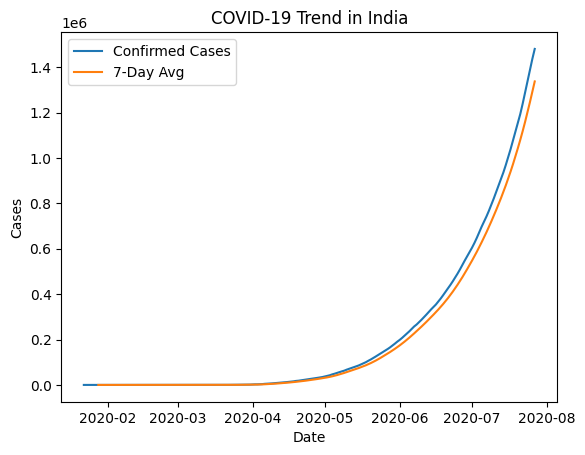

In [9]:
plt.figure()
plt.plot(df['Date'], df['Confirmed'], label='Confirmed Cases')
plt.plot(df['Date'], df['MA7'], label='7-Day Avg')
plt.legend()
plt.title("COVID-19 Trend in India")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.show()

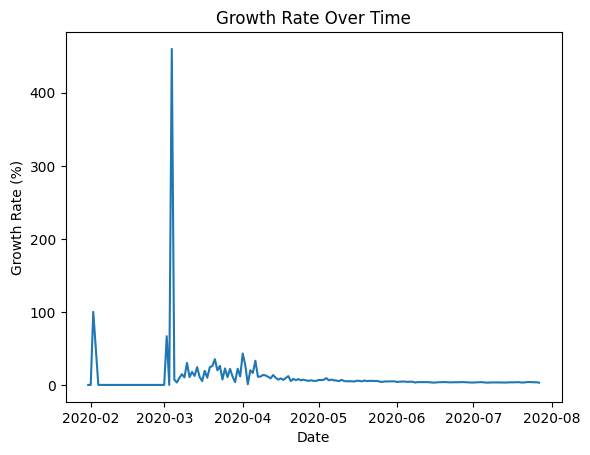

In [10]:
plt.figure()
plt.plot(df['Date'], df['Growth_Rate'])
plt.title("Growth Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Growth Rate (%)")
plt.show()

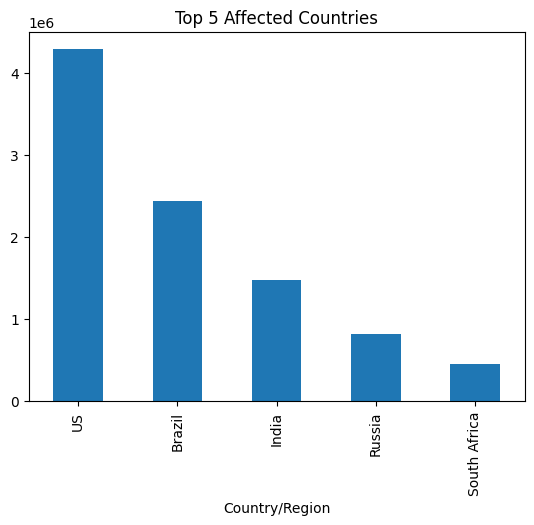

In [11]:
global_df = pd.read_csv("covid_19_clean_complete.csv")

top_countries = global_df.groupby('Country/Region')['Confirmed'].max().sort_values(ascending=False).head(5)

top_countries.plot(kind='bar')
plt.title("Top 5 Affected Countries")
plt.show()

In [12]:
peak = df.loc[df['Confirmed'].idxmax()]
print("Peak Day:", peak['Date'])

Peak Day: 2020-07-27 00:00:00


## 🤖 Predictive Analysis using Linear Regression

### 📌 Objective
To predict future COVID-19 confirmed cases in India using a machine learning model.

### 🧠 Approach
We used **Linear Regression** to model the relationship between time and confirmed cases.  
The `Date` column was converted into numerical format to train the model.

### 📊 Outcome
The model provides a simple trend-based prediction for future case counts.

### ⚠️ Limitation
Linear Regression assumes a linear trend and may not capture sudden spikes or waves.

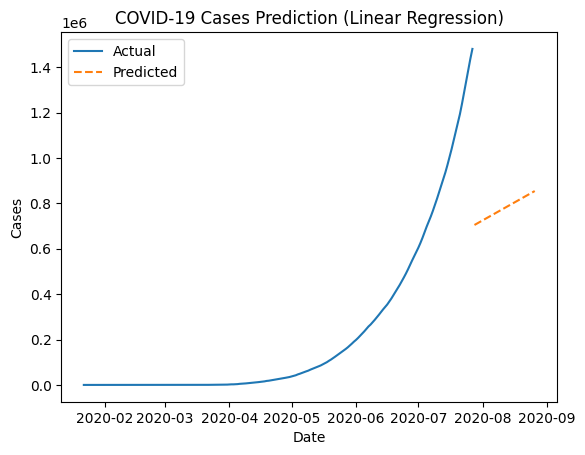

In [13]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Convert date to numeric
df['Date_Ordinal'] = df['Date'].map(pd.Timestamp.toordinal)

X = df[['Date_Ordinal']]
y = df['Confirmed']

# Train model
model = LinearRegression()
model.fit(X, y)

# Predict next 30 days 
future_dates = pd.date_range(start=df['Date'].max() + pd.Timedelta(days=1), periods=30)
future_ordinal = future_dates.map(pd.Timestamp.toordinal)

# Convert to DataFrame 
future_df = pd.DataFrame({'Date_Ordinal': future_ordinal})
predictions = model.predict(future_df)

# Plot
plt.figure()
# Actual data
plt.plot(df['Date'], df['Confirmed'], label='Actual')
# Predicted data
plt.plot(future_dates, predictions, linestyle='dashed',label='Predicted')

plt.legend()
plt.title("COVID-19 Cases Prediction (Linear Regression)")
plt.xlabel("Date")
plt.ylabel("Cases")

plt.show()

## 📈 Time Series Forecasting using ARIMA

### 📌 Objective
To forecast future COVID-19 cases using time-series modeling.

### 🧠 Approach
We used the **ARIMA model**, which is designed for time-series data and considers trends and patterns over time.

### 📊 Outcome
ARIMA provides more realistic forecasts compared to simple regression.

### ⚠️ Limitation
Requires parameter tuning and may be sensitive to data fluctuations.

In [14]:
!pip install --upgrade statsmodels

You should consider upgrading via the 'C:\Users\TANAY\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


C:\Users\TANAY\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\TANAY\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


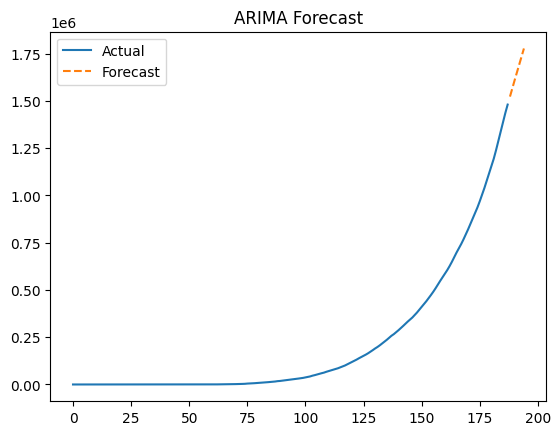

In [15]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model
model_arima = ARIMA(df['Confirmed'], order=(5,1,0))
model_arima_fit = model_arima.fit()

# Forecast next 7 days
forecast = model_arima_fit.forecast(steps=7)

# Plot
plt.figure()
plt.plot(df['Confirmed'], label='Actual')
plt.plot(range(len(df), len(df)+7), forecast, label='Forecast', linestyle='dashed')
plt.legend()
plt.title("ARIMA Forecast")
plt.show()

## 🎯 Classification of Risk Levels

### 📌 Objective
To classify COVID-19 severity into risk categories based on confirmed cases.

### 🧠 Approach
We categorized data into:
- Low Risk
- Medium Risk
- High Risk

Then applied a classification model to predict risk levels.

### 📊 Outcome
Helps in identifying severity levels for better decision-making.

### ⚠️ Limitation
Threshold-based classification may oversimplify real-world complexity.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Create risk levels
def risk_level(cases):
    if cases < 50000:
        return "Low"
    elif cases < 200000:
        return "Medium"
    else:
        return "High"

df['Risk_Level'] = df['Confirmed'].apply(risk_level)

# Features and target
X = df[['Confirmed', 'Deaths']]
y = df['Risk_Level']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

# Accuracy
accuracy = clf.score(X_test, y_test)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.9473684210526315


## 🧠 Key Insights

### 📈 Trend Analysis
- COVID-19 cases in India showed multiple waves, with significant spikes during peak periods  
- The second wave exhibited a much sharper rise compared to the first, indicating rapid spread  

---

### 📊 Growth Patterns
- The growth rate fluctuated heavily during early phases but stabilized over time  
- Moving averages helped smooth out daily variations and revealed underlying trends  

---

### ⚰️ Fatality Analysis
- Fatality rate decreased over time, suggesting improvements in healthcare infrastructure and treatment  
- Despite rising cases, death rates did not increase proportionally in later stages  

---

### 🌍 Comparative Insights
- A small number of countries contributed to the majority of global cases  
- India remained among the most affected countries during peak periods  

---

### 🤖 Machine Learning Insights
- Linear Regression successfully captured the overall trend of case growth  
- Predictions indicate continuation of trend but may not account for sudden changes  
- Classification model helped categorize risk levels (Low, Medium, High), useful for decision-making  

---

### 📊 Business/Real-World Impact
- Trend analysis can help governments plan healthcare resources  
- Risk classification can support decision-making for lockdowns and restrictions  
- Predictive models can assist in early warning systems  

---

### ⚠️ Limitations
- Models do not account for external factors like lockdowns, vaccination, or policy changes  
- ARIMA and regression models may produce warnings due to real-world data complexity  
- Predictions should be interpreted as approximations, not exact values  

---

### 💡 Conclusion
This analysis demonstrates how data analytics and machine learning can be applied to real-world datasets to extract insights, identify trends, and support data-driven decisions.